<a href="https://colab.research.google.com/github/jeremiahengoru-bit/MBMEClass2026/blob/main/SegmentationTechniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMAGE SEGMENTATION TECHNIQUES - COMPARATIVE ANALYSIS
Please upload an image file:


Saving glioma (37).jpg to glioma (37).jpg
Uploaded file: glioma (37).jpg
Resizing uploaded image to 256x256 for consistent processing.

Processing: glioma (37).jpg
✓ Otsu's method Completed
✓ Watershed completed
✓ K-Means completed
✓ Active Contour completed
Visualization saved to /mnt/user-data/outputs/Segmentation_Comparison_glioma_(37).jpg.png


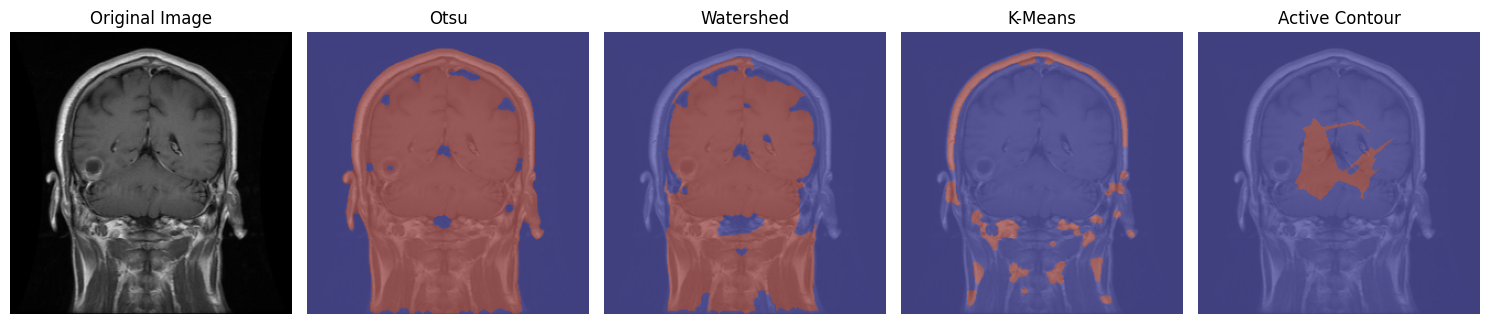


Performance Metrics Summary:

Image: glioma (37).jpg
Otsu            | Dice=0.238 | Jaccard=0.135 | Accuracy=0.551
Watershed       | Dice=0.146 | Jaccard=0.079 | Accuracy=0.614
K-Means         | Dice=0.861 | Jaccard=0.756 | Accuracy=0.981
Active Contour  | Dice=0.000 | Jaccard=0.000 | Accuracy=0.890

Segmentation complete! Results saved to /mnt/user-data/outputs/


In [ ]:
import numpy as np
import cv2
from scipy import ndimage
from scipy.ndimage import binary_dilation, binary_erosion
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')
import os
import tensorflow as tf
from google.colab import files
from PIL import Image
import io

class ImageUtils:
    @staticmethod
    def preprocess_image(image, blur_kernel=5, normalize=True, norm_method='minmax'):
        """
        Preprocess image for segmentation
        """
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Ensure kernel size is odd
        if blur_kernel % 2 == 0:
            blur_kernel += 1

        # Denoise
        image = cv2.GaussianBlur(image, (blur_kernel, blur_kernel), 0)

        # Normalize
        if normalize:
            if norm_method == 'minmax':
                image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            elif norm_method == 'zscore':
                image = (image - np.mean(image)) / (np.std(image) + 1e-8)
            elif norm_method == 'hist':
                image = cv2.equalizeHist(image.astype(np.uint8))

        return image

    @staticmethod
    def visualize_results(original, results_dict, save_path=None):
        """
        Visualize segmentation results from multiple methods

        Parameters:
        -----------
        original : np.ndarray
            Original image
        results_dict : dict
            Dictionary with technique names as keys and segmentation masks as values
        save_path : str, optional
            Path to save the visualization
        """
        n_methods = len(results_dict) + 1
        fig, axes = plt.subplots(1, n_methods, figsize=(15, 4))

        # Original image
        axes[0].imshow(original, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        # Segmentation results
        for idx, (method_name, segmentation) in enumerate(results_dict.items(), 1):
            if isinstance(segmentation, dict):
                # If it's a dict with 'mask' key
                mask = segmentation.get('mask', segmentation.get('segmentation', segmentation))
            else:
                mask = segmentation

            axes[idx].imshow(original, cmap='gray', alpha=0.5)
            axes[idx].imshow(mask, cmap='jet', alpha=0.5)
            axes[idx].set_title(f'{method_name}')
            axes[idx].axis('off')

        plt.tight_layout()

        if save_path:
            # Ensure the directory exists
            output_dir = os.path.dirname(save_path)
            if output_dir and not os.path.exists(output_dir):
                os.makedirs(output_dir, exist_ok=True)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Visualization saved to {save_path}")

        plt.show()

class MetricsUtils:
    @staticmethod
    def compute_metrics(ground_truth, predicted, threshold=0.5):
        """
        Compute segmentation metrics.

        Parameters
        ----------
        ground_truth : np.ndarray
            Ground truth binary mask.
        predicted : np.ndarray
            Predicted binary mask or probability map.
        threshold : float, optional
            Threshold for probability maps (default=0.5).

        Returns
        -------
        dict
            Dictionary containing Dice, Jaccard, Accuracy, Sensitivity, Specificity, and confusion matrix counts.
        """
        eps = np.finfo(float).eps

        # Ensure binary masks
        ground_truth = (ground_truth > 0).astype(np.uint8)
        if predicted.dtype != np.uint8:
            predicted = (predicted > threshold).astype(np.uint8)

        # Confusion matrix components
        TP = np.sum((predicted == 1) & (ground_truth == 1))
        FP = np.sum((predicted == 1) & (ground_truth == 0))
        FN = np.sum((predicted == 0) & (ground_truth == 1))
        TN = np.sum((predicted == 0) & (ground_truth == 0))

        # Metrics
        dice = 2 * TP / (2 * TP + FP + FN + eps)
        jaccard = TP / (TP + FP + FN + eps)
        accuracy = (TP + TN) / (TP + TN + FP + FN + eps)
        sensitivity = TP / (TP + FN + eps)
        specificity = TN / (TN + FP + eps)

        return {
            'Dice': dice,
            'Jaccard': jaccard,
            'Accuracy': accuracy,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'TP': TP,
            'FP': FP,
            'FN': FN,
            'TN': TN
        }

# ============================================================================
# TECHNIQUE 1: Otsu's (Thresholding-based segmentation)
# ============================================================================

class OtsuSegmenter:
    """
    Otsu's thresholding-based segmentation.
    """

    def segment(self, image):
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Apply Otsu's threshold
        _, segmentation = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological cleanup
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        segmentation = cv2.morphologyEx(segmentation, cv2.MORPH_CLOSE, kernel)

        return {
            'segmentation': segmentation,
            'mask': (segmentation > 127).astype(np.uint8),
            'method': 'Otsu Thresholding',
            'description': 'Automatic thresholding using Otsu’s method'
        }
# ============================================================================
# TECHNIQUE 2: WATERSHED ALGORITHM (Morphological Segmentation)
# ============================================================================
class WatershedSegmenter:
    """
    Watershed segmentation using morphological operations
    """

    def __init__(self, connectivity=8, closing_kernel_size=5):
        """
        Initialize Watershed segmenter

        Parameters:
        -----------
        connectivity : int
            Connectivity for watershed (4 or 8)
        closing_kernel_size : int
            Kernel size for morphological closing
        """
        self.connectivity = connectivity
        self.closing_kernel_size = closing_kernel_size

    def segment(self, image):
        """
        Perform watershed segmentation

        Parameters:
        -----------
        image : np.ndarray
            Input image (should be single channel)

        Returns:
        --------
        dict
            Segmentation results
        """
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Step 1: Preprocessing
        # Apply morphological opening to remove small noise
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        cleaned = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

        # Step 2: Compute binary image
        # Otsu's thresholding for automatic threshold selection
        _, binary = cv2.threshold(cleaned, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Step 3: Compute distance transform
        # Distance from each pixel to background
        dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)

        # Normalize distance transform
        dist_transform = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Step 4: Find markers (regional maxima of distance transform)
        # Threshold to get sure foreground
        _, sure_foreground = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
        sure_foreground = np.uint8(sure_foreground)

        # Find connected components as markers
        num_markers, markers = cv2.connectedComponents(sure_foreground, connectivity=self.connectivity)
        # Step 5: Apply watershed
        # Mark background as 1
        markers = markers + 1
        # Mark unknown area as 0
        unknown = cv2.subtract(binary, sure_foreground)
        markers[unknown == 255] = 0

        # Apply watershed
        image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        markers = cv2.watershed(image_color, markers)

        # Step 6: Create segmentation mask
        # Pixels with value -1 are watershed boundaries
        segmentation = np.zeros_like(image)
        segmentation[markers > 1] = 255

        # Post-processing: morphological closing
        closing_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (self.closing_kernel_size, self.closing_kernel_size)
        )
        segmentation = cv2.morphologyEx(segmentation, cv2.MORPH_CLOSE, closing_kernel)

        return {
            'segmentation': segmentation,
            'mask': (segmentation > 127).astype(np.uint8),
            'markers': markers,
            'distance_transform': dist_transform,
            'method': 'Watershed Algorithm',
            'description': 'Morphological segmentation using distance transform and watershed'
        }

# ============================================================================
# TECHNIQUE 3: K-MEANS CLUSTERING (Unsupervised Learning)
# ============================================================================
class KMeansSegmenter:
    """
    K-Means clustering-based image segmentation.
    """

    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        """
        Initialize K-Means segmenter.

        Parameters
        ----------
        n_clusters : int
            Number of clusters/segments.
        max_iter : int
            Maximum iterations for K-Means.
        random_state : int
            Random seed for reproducibility.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.kmeans = None

    def segment(self, image, use_spatial_features=False, foreground_strategy="brightest"):
        """
        Perform K-Means segmentation.

        Parameters
        ----------
        image : np.ndarray
            Input image.
        use_spatial_features : bool
            If True, include pixel coordinates as features.
        foreground_strategy : str or int
            Strategy to select foreground cluster:
            - "brightest": cluster with highest mean intensity
            - "darkest": cluster with lowest mean intensity
            - int: specific cluster index

        Returns
        -------
        dict
            Segmentation results.
        """
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Normalize image
        image_norm = image.astype(np.float32) / 255.0
        h, w = image.shape

        # Prepare features
        features = image_norm.reshape(-1, 1)
        if use_spatial_features:
            y_coords, x_coords = np.mgrid[0:h, 0:w]
            x_coords = x_coords.reshape(-1, 1) / w
            y_coords = y_coords.reshape(-1, 1) / h
            features = np.hstack([features, x_coords, y_coords])

        # Apply K-Means
        self.kmeans = KMeans(
            n_clusters=self.n_clusters,
            max_iter=self.max_iter,
            random_state=self.random_state,
            n_init=10
        )
        labels = self.kmeans.fit_predict(features)
        segmentation_labeled = labels.reshape(h, w)

        # Compute cluster intensities
        cluster_intensities = [
            image[segmentation_labeled == i].mean() for i in range(self.n_clusters)
        ]

        # Select foreground cluster
        if foreground_strategy == "brightest":
            foreground_cluster = np.argmax(cluster_intensities)
        elif foreground_strategy == "darkest":
            foreground_cluster = np.argmin(cluster_intensities)
        else:
            foreground_cluster = int(foreground_strategy)

        # Create segmentation mask
        segmentation = (segmentation_labeled == foreground_cluster).astype(np.uint8) * 255

        # Post-processing: morphological operations
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        segmentation = cv2.morphologyEx(segmentation, cv2.MORPH_CLOSE, kernel)
        segmentation = cv2.morphologyEx(segmentation, cv2.MORPH_OPEN, kernel)

        return {
            'segmentation': segmentation,
            'mask': (segmentation > 127).astype(np.uint8),
            'labels': segmentation_labeled,
            'centers': self.kmeans.cluster_centers_,
            'cluster_intensities': cluster_intensities,
            'method': 'K-Means Clustering',
            'description': f'Unsupervised segmentation using K-Means with {self.n_clusters} clusters'
        }

# ============================================================================
# TECHNIQUE 4: ACTIVE CONTOUR MODEL (Physics-Based Segmentation)
# ============================================================================

class ActiveContourSegmenter:
    """
    Active Contour (Snake) model for image segmentation
    Implementation using simplified level set method.
    """

    def __init__(self, alpha=0.1, beta=0.1, gamma=0.1, iterations=100):
        """
        Initialize Active Contour segmenter.

        Parameters
        ----------
        alpha : float
            Elasticity weight (smoothness, first derivative).
        beta : float
            Rigidity weight (bending resistance, second derivative).
        gamma : float
            External force weight.
        iterations : int
            Number of iterations.
        """
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.iterations = iterations

    def _compute_external_force(self, image):
        """Compute external force from image gradients."""
        blurred = cv2.GaussianBlur(image, (5, 5), 1.0)
        gx = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)
        grad_magnitude = np.sqrt(gx**2 + gy**2)
        external_force = -grad_magnitude
        return external_force, gx, gy

    def _initialize_contour(self, image, method='circle', num_points=100):
        """Initialize contour (snake)."""
        h, w = image.shape
        if method == 'circle':
            center_x, center_y = w // 2, h // 2
            radius = min(h, w) // 4
            angles = np.linspace(0, 2*np.pi, num_points)
            contour = np.column_stack([
                center_x + radius * np.cos(angles),
                center_y + radius * np.sin(angles)
            ])
        elif method == 'rectangle':
            margin = 50
            contour_x = np.concatenate([
                np.linspace(margin, w-margin, num_points//4),
                np.ones(num_points//4) * (w-margin),
                np.linspace(w-margin, margin, num_points//4),
                np.ones(num_points//4) * margin
            ])
            contour_y = np.concatenate([
                np.ones(num_points//4) * margin,
                np.linspace(margin, h-margin, num_points//4),
                np.ones(num_points//4) * (h-margin),
                np.linspace(h-margin, margin, num_points//4)
            ])
            contour = np.column_stack([contour_x, contour_y])
        return contour.astype(np.float32)

    def segment(self, image, init_method='circle'):
        """Perform active contour segmentation."""
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        h, w = image.shape

        external_force, gx, gy = self._compute_external_force(image)
        contour = self._initialize_contour(image, method=init_method)

        # Iterative contour deformation
        for iteration in range(self.iterations):
            n_points = len(contour)
            laplacian = np.zeros_like(contour)
            curvature = np.zeros_like(contour)

            for i in range(n_points):
                prev_idx = (i - 1) % n_points
                next_idx = (i + 1) % n_points
                # Smoothness (first derivative)
                laplacian[i] = (contour[prev_idx] + contour[next_idx] - 2 * contour[i])
                # Rigidity (second derivative)
                curvature[i] = (contour[next_idx] - 2 * contour[i] + contour[prev_idx])

            external_forces = np.zeros_like(contour)
            for i in range(n_points):
                x, y = int(np.clip(contour[i, 0], 0, w-1)), int(np.clip(contour[i, 1], 0, h-1))
                external_forces[i, 0] = gx[y, x]
                external_forces[i, 1] = gy[y, x]

            # Update contour with all forces
            contour = contour + self.alpha * laplacian + self.beta * curvature + self.gamma * external_forces
            contour[:, 0] = np.clip(contour[:, 0], 0, w-1)
            contour[:, 1] = np.clip(contour[:, 1], 0, h-1)

        # Create mask from final contour
        mask = np.zeros((h, w), dtype=np.uint8)
        contour_int = contour.astype(np.int32)
        cv2.drawContours(mask, [contour_int], 0, 255, -1)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        return {
            'segmentation': mask,
            'mask': (mask > 127).astype(np.uint8),
            'contour': contour,
            'method': 'Active Contour Model',
            'description': f'Snake model with alpha={self.alpha}, beta={self.beta}, gamma={self.gamma}, iterations={self.iterations}'
        }

# ============================================================================
# MAIN DEMONSTRATION
# ============================================================================

def main():
    """
    Main function demonstrating all four segmentation techniques
    with Colab image upload only (no sample images).
    """
    print("=" * 70)
    print("IMAGE SEGMENTATION TECHNIQUES - COMPARATIVE ANALYSIS")
    print("=" * 70)

    # ------------------------------------------------------------------------
    # Upload image in Colab
    # ------------------------------------------------------------------------
    print("Please upload an image file:")
    uploaded = files.upload()

    if not uploaded:
        print("No image uploaded. Please upload an image to proceed.")
        return

    # Load the uploaded image
    for filename in uploaded.keys():
        print(f"Uploaded file: {filename}")
        image_data = uploaded[filename]
        image = Image.open(io.BytesIO(image_data)).convert("L")  # grayscale
        image_np = np.array(image)

        # Resize to 256x256 for consistency
        if image_np.shape[:2] != (256, 256):
            print("Resizing uploaded image to 256x256 for consistent processing.")
            image_np = cv2.resize(image_np, (256, 256))

        test_images = {filename: image_np}

    # ------------------------------------------------------------------------
    # Demonstrate each technique
    # ------------------------------------------------------------------------
    all_metrics = {}

    for img_name, original_image in test_images.items():
        print(f"\n{'=' * 70}")
        print(f"Processing: {img_name}")
        print(f"{'=' * 70}")

        processed = ImageUtils.preprocess_image(original_image)
        results = {}
        metrics_summary = {}

        # Otsu's
        try:
            otsu = OtsuSegmenter()
            otsu_result = otsu.segment(processed)
            results['Otsu'] = otsu_result['segmentation']
            metrics_summary['Otsu'] = MetricsUtils.compute_metrics(processed > 127, otsu_result['mask'])
            print("✓ Otsu's method Completed")
        except Exception as e:
            print(f"✗ Error: {e}")
        # Watershed
        try:
            watershed = WatershedSegmenter()
            watershed_result = watershed.segment(processed)
            results['Watershed'] = watershed_result['segmentation']
            metrics_summary['Watershed'] = MetricsUtils.compute_metrics(processed > 127, watershed_result['mask'])
            print("✓ Watershed completed")
        except Exception as e:
            print(f"Watershed error: {e}")

        # K-Means
        try:
            kmeans = KMeansSegmenter(n_clusters=3)
            kmeans_result = kmeans.segment(processed)
            results['K-Means'] = kmeans_result['segmentation']
            metrics_summary['K-Means'] = MetricsUtils.compute_metrics(processed > 127, kmeans_result['mask'])
            print("✓ K-Means completed")
        except Exception as e:
            print(f"K-Means error: {e}")

        # Active Contour
        try:
            snake = ActiveContourSegmenter(alpha=0.05, beta=0.05, gamma=0.5, iterations=100)
            snake_result = snake.segment(processed)
            results['Active Contour'] = snake_result['segmentation']
            metrics_summary['Active Contour'] = MetricsUtils.compute_metrics(processed > 127, snake_result['mask'])
            print("✓ Active Contour completed")
        except Exception as e:
            print(f"Active Contour error: {e}")

        # Visualization
        if results:
            ImageUtils.visualize_results(
                original_image,
                results,
                save_path=f'/mnt/user-data/outputs/Segmentation_Comparison_{img_name.replace(" ", "_")}.png'
            )
        else:
            print("No segmentation results to visualize.")

        all_metrics[img_name] = metrics_summary

    # ------------------------------------------------------------------------
    # Performance Summary
    # ------------------------------------------------------------------------
    print("\nPerformance Metrics Summary:")
    for img_name, methods in all_metrics.items():
        print(f"\nImage: {img_name}")
        for method, m in methods.items():
            print(f"{method:15} | Dice={m['Dice']:.3f} | Jaccard={m['Jaccard']:.3f} | Accuracy={m['Accuracy']:.3f}")

    print("\nSegmentation complete! Results saved to /mnt/user-data/outputs/")

if __name__ == "__main__":
    main()